Fetching Olivetti Faces dataset...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset Shape: 400 images, 4096 features (pixels) per image.


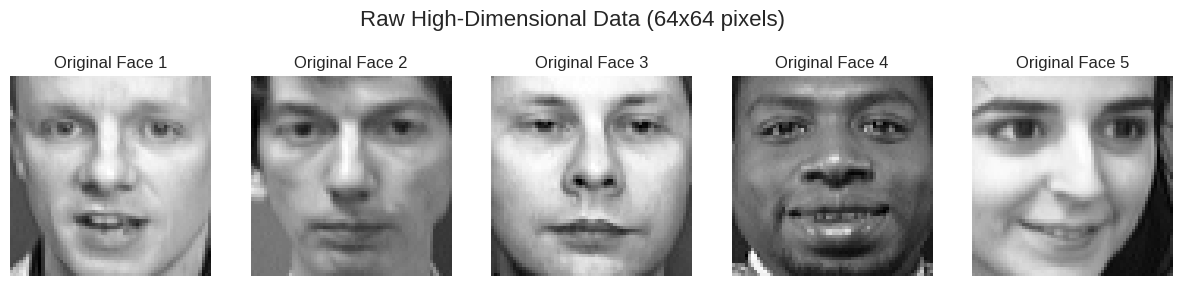

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Set styling for professional plots
plt.style.use('seaborn-v0_8-darkgrid')

print("Fetching Olivetti Faces dataset...")
dataset = fetch_olivetti_faces(shuffle=True, random_state=42)

# faces_matrix shape: (400, 4096) - 400 images, each is a 4096-dimensional vector
faces_matrix = dataset.data
# faces_images shape: (400, 64, 64) - For visualization only
faces_images = dataset.images

n_samples, n_features = faces_matrix.shape
print(f"Dataset Shape: {n_samples} images, {n_features} features (pixels) per image.")

# Visualize the raw, high-dimensional data
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(faces_images[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Original Face {i+1}")
plt.suptitle("Raw High-Dimensional Data (64x64 pixels)", fontsize=16, y=1.05)
plt.show()

Similarity Score (Face A vs Face B): 0.9450
Similarity Score (Face A vs itself):  1.0000


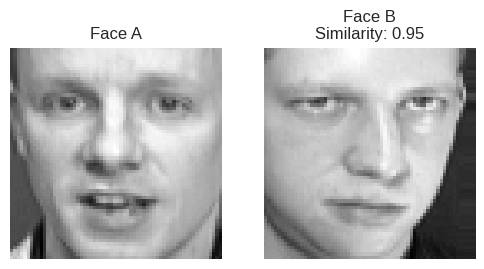

In [2]:
def cosine_similarity(v1, v2):
    """Calculates the cosine of the angle between two vectors."""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

# Select two distinct faces and one identical face for baseline
face_A = faces_matrix[0]
face_B = faces_matrix[10]

sim_different = cosine_similarity(face_A, face_B)
sim_identical = cosine_similarity(face_A, face_A)

print(f"Similarity Score (Face A vs Face B): {sim_different:.4f}")
print(f"Similarity Score (Face A vs itself):  {sim_identical:.4f}")

# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(faces_images[0], cmap='gray')
axes[0].set_title("Face A")
axes[0].axis('off')

axes[1].imshow(faces_images[10], cmap='gray')
axes[1].set_title(f"Face B\nSimilarity: {sim_different:.2f}")
axes[1].axis('off')
plt.show()

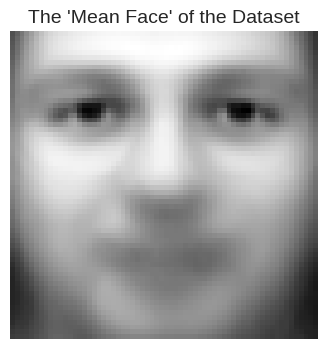

In [3]:
# Calculate the 'Average Face' across all 400 images
mean_face = np.mean(faces_matrix, axis=0)

# Center the data by subtracting the mean
centered_faces = faces_matrix - mean_face

# Visualize the Mean Face
plt.figure(figsize=(4, 4))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title("The 'Mean Face' of the Dataset", fontsize=14)
plt.axis('off')
plt.show()

Performing Singular Value Decomposition (SVD)...


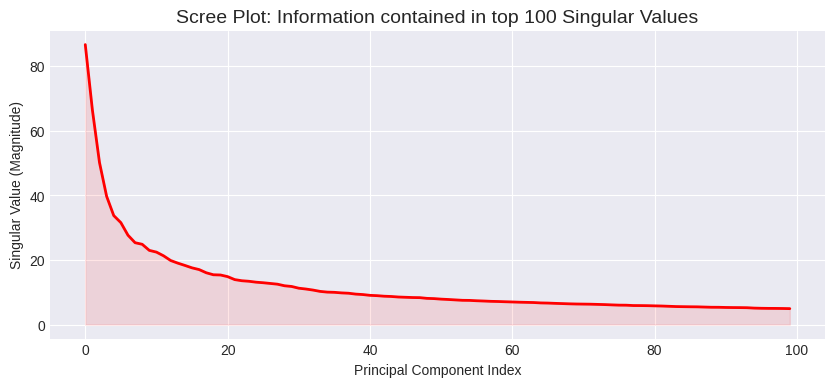

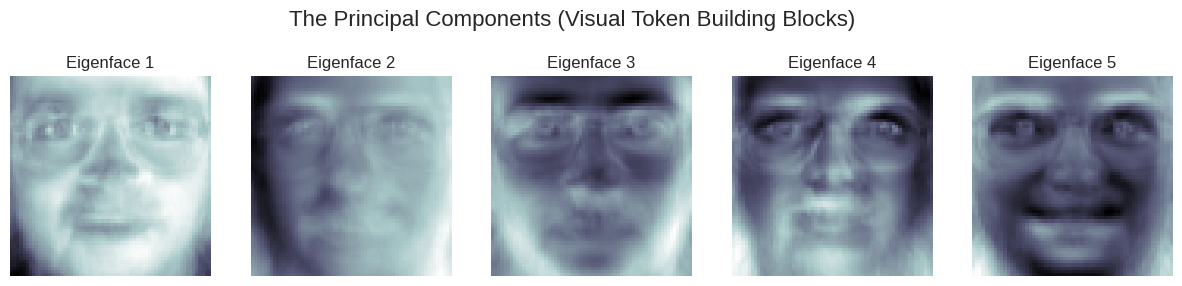

In [4]:
print("Performing Singular Value Decomposition (SVD)...")
# A = U * S * V^T
# Vt (V-transpose) contains the principal directions (Eigenvectors)
U, S, Vt = np.linalg.svd(centered_faces, full_matrices=False)

# 1. The Scree Plot: Showing Information Drop-off
plt.figure(figsize=(10, 4))
plt.plot(S[:100], color='red', linewidth=2)
plt.fill_between(range(100), S[:100], color='red', alpha=0.1)
plt.title("Scree Plot: Information contained in top 100 Singular Values", fontsize=14)
plt.xlabel("Principal Component Index")
plt.ylabel("Singular Value (Magnitude)")
plt.show()

# 2. Visualize the top 5 Eigenfaces (The building blocks)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Reshape the 4096D eigenvector back into a 64x64 image
    eigenface = Vt[i].reshape(64, 64)
    axes[i].imshow(eigenface, cmap='bone')
    axes[i].axis('off')
    axes[i].set_title(f"Eigenface {i+1}")
plt.suptitle("The Principal Components (Visual Token Building Blocks)", fontsize=16, y=1.05)
plt.show()

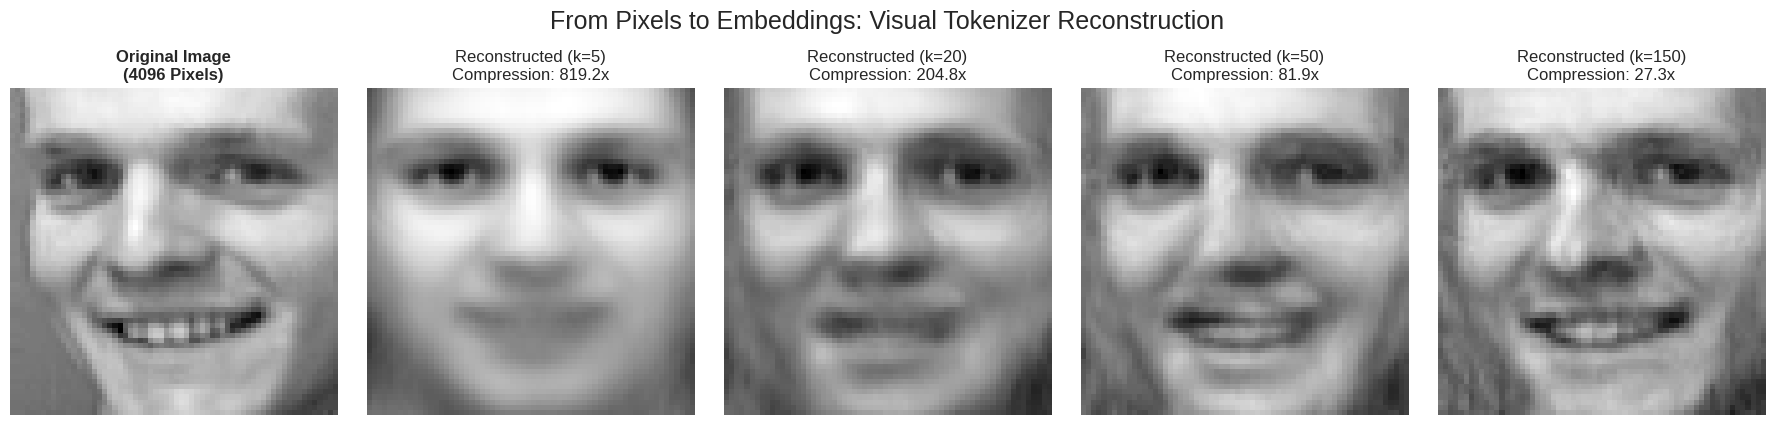

In [7]:
def encode_and_decode(face_vector, principal_components, mean_data, k):
    """
    Compresses a face to k dimensions, then reconstructs it.
    """
    # ENCODE: Project the face onto the top k eigenfaces (Dimensionality Reduction)
    # This creates a vector of 'k' weights (our embeddings!)
    embeddings = np.dot(face_vector, principal_components[:k].T)

    # DECODE: Rebuild the face using only those 'k' weights and add the mean back
    reconstruction = np.dot(embeddings, principal_components[:k]) + mean_data
    return reconstruction.reshape(64, 64)

# Pick a random test face that the algorithm hasn't been specifically trained on
test_index = 50
test_face_centered = centered_faces[test_index]
original_test_image = faces_images[test_index]

# Set our compression levels (number of embeddings)
k_values = [5, 20, 50, 150]

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(18, 4))

# Plot Original
axes[0].imshow(original_test_image, cmap='gray')
axes[0].set_title("Original Image\n(4096 Pixels)", fontweight='bold')
axes[0].axis('off')

# Plot Reconstructions
for i, k in enumerate(k_values):
    reconstructed_img = encode_and_decode(test_face_centered, Vt, mean_face, k)

    # Calculate Compression Ratio
    compression_ratio = 4096 / k

    axes[i+1].imshow(reconstructed_img, cmap='gray')
    axes[i+1].set_title(f"Reconstructed (k={k})\nCompression: {compression_ratio:.1f}x")
    axes[i+1].axis('off')

plt.suptitle("From Pixels to Embeddings: Visual Tokenizer Reconstruction", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()